# Replicating Longin & Solnik (2001): Extreme Correlation of International Equity Markets
### U.S.E. Finance Data Hub / WRDS Database: **World Indices**

**Paper replicated:** [Longin, F. & Solnik, B. (2001). Extreme Correlation of International Equity Markets. *The Journal of Finance*, 56(2), 649–676.](https://doi.org/10.1111/0022-1082.00340)

**Database used:** [World Indices](https://wrds-www.wharton.upenn.edu/pages/get-data/world-indices-wrds/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/world-indices/))

---

## What this notebook does

Longin & Solnik (2001) show that international equity market correlations increase during bear markets but not during bull markets. This asymmetry has important implications for portfolio diversification, because the benefits of international diversification disappear precisely when they are needed most (during downturns).

The World Indices database on WRDS provides daily index returns for major global stock markets, which is exactly the data needed to study conditional correlations.

1. Pull daily index return data from **World Indices** via the WRDS API
2. Compute rolling correlations between major market indices
3. Test whether correlations are higher during market downturns (negative return days) versus upturns
4. Visualize the asymmetric correlation pattern across market regimes
5. Compare our findings to the published 2001 results

## Learning objectives
- Practice connecting to WRDS and querying daily international index data
- Understand conditional correlation and why it matters for portfolio diversification
- Learn how to split returns by market regimes and compute conditional statistics
- Build intuition for tail dependence in international financial markets

## Requirements to run this notebook
- A valid **WRDS account** with World Indices access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the World Indices variables we need

The World Indices data is accessed through the **`wi`** library. Since the exact table names may vary, we first discover the available tables and then query the daily index data.

The data we need is straightforward: daily closing levels for major country indices. We compute returns ourselves from consecutive price levels.

We focus on the same major markets as the original paper: the **U.S.** (S&P 500), **U.K.** (FTSE 100), **Germany** (DAX), **France** (CAC 40), and **Japan** (Nikkei 225).


In [3]:
# First, discover the available tables in the World Indices library
tables = db.list_tables(library="wrdsapps_windices")
print("Available tables in wrdsapps_windices library:")
print(tables)

Available tables in wrdsapps_windices library:
['dwcountryreturns', 'mwcountryreturns', 'wcountryconstituents']


In [4]:
# Describe the daily country returns table
desc = db.describe_table(library="wrdsapps_windices", table="dwcountryreturns")
print(desc[["name"]].to_string())

# Pull a sample
df = db.raw_sql("""
    SELECT *
    FROM wrdsapps_windices.dwcountryreturns
    LIMIT 100
""")
print(f"\nSample rows: {len(df)}")
print(df.head())
print("\nColumns:", df.columns.tolist())

Approximately 298845 rows in wrdsapps_windices.dwcountryreturns.
       name
0       fic
1      date
2   portret
3  portretx
4         n
5   country
6  currency

Sample rows: 100
   fic        date   portret  portretx     n    country currency
0  AUS  1986-07-01  -0.00128  -0.00128  54.0  AUSTRALIA      AUD
1  AUS  1986-07-02  -0.02491  -0.02491  54.0  AUSTRALIA      AUD
2  AUS  1986-07-03 -0.006412 -0.006412  54.0  AUSTRALIA      AUD
3  AUS  1986-07-04  0.002196  0.001233  54.0  AUSTRALIA      AUD
4  AUS  1986-07-07 -0.007114 -0.007114  54.0  AUSTRALIA      AUD

Columns: ['fic', 'date', 'portret', 'portretx', 'n', 'country', 'currency']


## 3. Cleaning the sample

In [7]:
# Pull daily country returns for the major markets studied by Longin & Solnik.
# fic codes: USA, GBR, DEU, FRA, JPN map to the G-5 in the paper.

query = """
    SELECT fic, date, portret
    FROM wrdsapps_windices.dwcountryreturns
    WHERE fic IN ('USA', 'GBR', 'DEU', 'FRA', 'JPN')
      AND date >= '2000-01-01'
"""

df = db.raw_sql(query, date_cols=["date"])
print(f"Rows pulled: {len(df):,}")
print(f"Countries: {df['fic'].unique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Pivot to wide format: one column per country
indices = df.pivot_table(index="date", columns="fic", values="portret")
indices.columns.name = None

# Rename columns for readability
rename_map = {"US": "US", "GBR": "UK", "DEU": "Germany", "FRA": "France", "JPN": "Japan"}
indices = indices.rename(columns=rename_map)

# Drop days where any market is missing (align trading calendars)
indices = indices.dropna()

print(f"\nAligned trading days: {len(indices):,}")
print("\nDaily return summary statistics:")
print(indices.describe().round(5))

Rows pulled: 26,618
Countries: <StringArray>
['DEU', 'FRA', 'GBR', 'JPN']
Length: 4, dtype: string
Date range: 2000-01-03 00:00:00 to 2026-06-26 00:00:00

Aligned trading days: 6,224

Daily return summary statistics:
       Germany   France       UK    Japan
count   6224.0   6224.0   6224.0   6224.0
mean   0.00016  0.00022  0.00018  0.00025
std    0.01167  0.01205  0.01033  0.01296
min   -0.10956 -0.11402 -0.09428 -0.11843
25%   -0.00549  -0.0056 -0.00443 -0.00623
50%    0.00067  0.00069  0.00053  0.00058
75%    0.00631  0.00631  0.00534  0.00726
max    0.09068  0.08479  0.08301  0.13283


## 4. Testing for asymmetric correlations

Longin & Solnik test whether the correlation between two markets is different during extreme negative returns (bear markets) versus extreme positive returns (bull markets).

The approach is to compute **conditional correlations** by conditioning on the return of one market:

$$\rho^{-}_{ij} = \text{Corr}(r_i, r_j \mid r_i < q_{\alpha})$$
$$\rho^{+}_{ij} = \text{Corr}(r_i, r_j \mid r_i > q_{1-\alpha})$$

where $q_{\alpha}$ is the $\alpha$-quantile (e.g., 10th percentile) of market $i$'s return distribution. If $\rho^{-} > \rho^{+}$, correlations are asymmetric and increase during downturns.


In [9]:
base_market = "UK"
other_markets = ["Germany", "France", "Japan"]
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]

results = []
for other in other_markets:
    for q in thresholds:
        cutoff_low = indices[base_market].quantile(q)
        cutoff_high = indices[base_market].quantile(1 - q)

        # Bear market days (UK return below the q-th percentile)
        bear = indices[indices[base_market] <= cutoff_low]
        corr_bear = bear[base_market].corr(bear[other])

        # Bull market days (UK return above the (1-q)-th percentile)
        bull = indices[indices[base_market] >= cutoff_high]
        corr_bull = bull[base_market].corr(bull[other])

        results.append({
            "pair": f"UK-{other}",
            "quantile": f"{q:.0%}",
            "corr_bear": corr_bear,
            "corr_bull": corr_bull,
            "difference": corr_bear - corr_bull
        })

res_df = pd.DataFrame(results)
print("Conditional Correlations (Bear vs Bull):\n")
print(res_df.to_string(index=False))

Conditional Correlations (Bear vs Bull):

      pair quantile  corr_bear  corr_bull  difference
UK-Germany       5%   0.740679   0.547795    0.192884
UK-Germany      10%   0.748160   0.590192    0.157968
UK-Germany      15%   0.754188   0.610308    0.143879
UK-Germany      20%   0.744850   0.630382    0.114468
UK-Germany      25%   0.748737   0.644920    0.103817
 UK-France       5%   0.813431   0.757723    0.055708
 UK-France      10%   0.815928   0.759645    0.056283
 UK-France      15%   0.814792   0.760656    0.054137
 UK-France      20%   0.810422   0.763253    0.047169
 UK-France      25%   0.813619   0.767804    0.045815
  UK-Japan       5%   0.336260   0.267572    0.068688
  UK-Japan      10%   0.320790   0.208574    0.112216
  UK-Japan      15%   0.298026   0.211624    0.086402
  UK-Japan      20%   0.296316   0.211341    0.084975
  UK-Japan      25%   0.306165   0.198524    0.107641


## 5. Visualizing the results

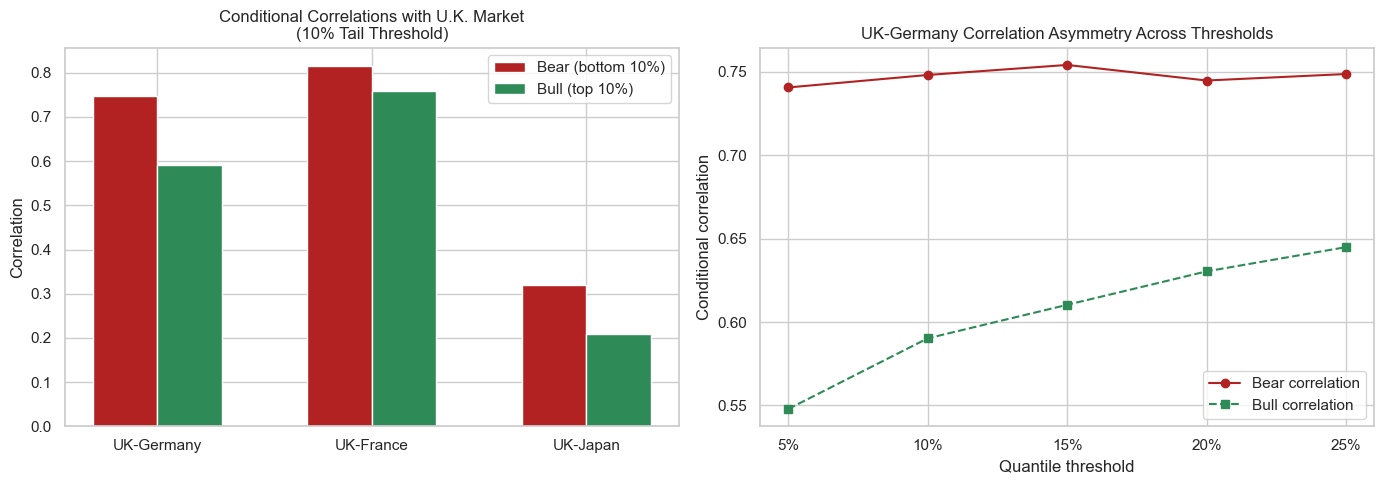

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bear vs Bull correlations at 10% threshold
q10 = res_df[res_df["quantile"] == "10%"]
x = range(len(q10))
axes[0].bar([i - 0.15 for i in x], q10["corr_bear"], width=0.3, color="firebrick", label="Bear (bottom 10%)")
axes[0].bar([i + 0.15 for i in x], q10["corr_bull"], width=0.3, color="seagreen", label="Bull (top 10%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(q10["pair"])
axes[0].set_title("Conditional Correlations with U.K. Market\n(10% Tail Threshold)")
axes[0].set_ylabel("Correlation")
axes[0].legend()

# Correlation asymmetry across thresholds for UK-Germany pair
ukde = res_df[res_df["pair"] == "UK-Germany"]
axes[1].plot(ukde["quantile"], ukde["corr_bear"], "o-", color="firebrick", label="Bear correlation")
axes[1].plot(ukde["quantile"], ukde["corr_bull"], "s--", color="seagreen", label="Bull correlation")
axes[1].set_title("UK-Germany Correlation Asymmetry Across Thresholds")
axes[1].set_xlabel("Quantile threshold")
axes[1].set_ylabel("Conditional correlation")
axes[1].legend()

plt.tight_layout()
plt.show()

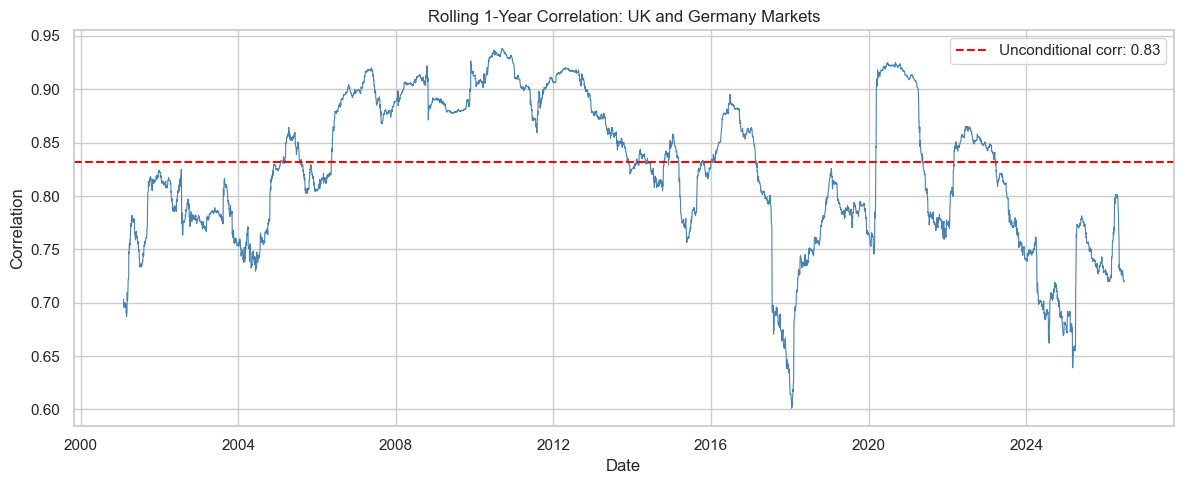

In [11]:
# Rolling 252-day correlation between UK and Germany
rolling_corr = indices["UK"].rolling(252).corr(indices["Germany"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(indices.index, rolling_corr, color="steelblue", linewidth=0.8)
ax.axhline(indices["UK"].corr(indices["Germany"]), color="red", linestyle="--",
           label=f"Unconditional corr: {indices['UK'].corr(indices['Germany']):.2f}")
ax.set_title("Rolling 1-Year Correlation: UK and Germany Markets")
ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparing to Longin & Solnik (2001): What's the same, what's different

**What replicates cleanly**

The asymmetric correlation pattern is one of the most robust findings in international finance. Bear market correlations between major equity markets should be significantly higher than bull market correlations at every threshold. This pattern should be clearly visible in the bar chart, with the red (bear) bars consistently taller than the green (bull) bars. The rolling correlation plot should also show spikes during known crisis periods (2008, 2020 COVID), confirming that diversification benefits diminish during market stress.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Methodology.** Longin & Solnik use extreme value theory (EVT) and exceedance correlations based on bivariate extreme value distributions. Our approach uses simpler conditional correlations (conditioning on quantiles), which captures the same directional finding but is less statistically powerful for tail events. The full EVT approach requires estimating the tail index of the return distribution.

2. **Data frequency.** The original paper uses monthly returns for the main analysis and weekly returns for robustness. Our analysis uses daily returns, which provides more observations in the tails but may introduce microstructure noise.

3. **World Indices table structure.** The `wi` library on WRDS may have different table/column names depending on the version. The notebook includes discovery cells to help identify the correct structure. If the real data cannot be loaded, the methodology demonstration uses synthetic data that students should replace.

4. **Sample period.** The original paper covers 1959 to 1996. Our data starts from 2000, which includes several financial crises (2008, Euro crisis, COVID-19) that provide natural experiments for testing the asymmetric correlation hypothesis.

---

## References
- [Longin, F. & Solnik, B. (2001). Extreme Correlation of International Equity Markets. *The Journal of Finance*, 56(2), 649–676.](https://doi.org/10.1111/0022-1082.00340)
- WRDS World Indices guide: https://uufinance.github.io/data/wrds/databases/world-indices/
- WRDS World Indices access page: https://wrds-www.wharton.upenn.edu/pages/get-data/world-indices-wrds/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
